In [2]:
import sys
sys.path.append("/users/stalaei/code/pass_at_k")
from custom.countdown_verifier import countdown_compute_score

In [3]:
sample_response = "<think>\nTo create an expression that equals 96 using the numbers 55, 49, and 16, I'll start by considering the operations and the numbers available. Given that 96 is a relatively large number, it's likely that multiplication or a combination of operations will be needed. \n\nFirst, let's see if we can use the largest number, 55, in a way that helps us reach 96. If we multiply 55 by 2, we get 110, which is close to 96 but too high. If we divide 55 by 2, we get 27.5, which is not an integer and not helpful. \n\nNext, let's consider using 49 and 16. If we add 49 and 16, we get 65, which is still far from 96. If we subtract 16 from 49, we get 33, which is closer but still not 96. \n\nNow, let's try to use 55 and 16 together. If we subtract 16 from 55, we get 39. Now, we need to get from 39 to 96. We can do this by multiplying 39 by 2.5, but since we can't use fractions, we need to find another way. \n\nLet's try another approach: if we multiply 16 by 3, we get 48. Now, we need to get from 48 to 48 more to reach 96. We can do this by adding 48 to 48, which is 96. \n\nSo, the expression would be: (16 * 3) + 48 = 96.\n</think>\n\n<answer>\n(16 * 3) + 48\n</answer>"

In [4]:
gts = "96"

countdown_compute_score(
    data_source=None,
    solution_str=sample_response,
    ground_truth=gts,
    extra_info={
        "nums": [55, 49, 16]
    }
)

(16 * 3) + 48


0.0

In [5]:
sample_response = "<answer>(6+3)*(58-47)</answer>"
gts = 99

countdown_compute_score(
    data_source=None,
    solution_str=sample_response,
    ground_truth=gts,
    extra_info={
        "nums": [47, 58, 6, 3]
    }
)

(6+3)*(58-47)


1.0

## Playing with the prompt to get the multi-attempt thinking right 

In [8]:
import sys
sys.path.append("/users/stalaei/code/pass_at_k")
from custom.model_inference import load_model, generate_text
import os
HF_HOME = os.environ.get("HF_HOME", os.path.expanduser("~"))

model = load_model(f"{HF_HOME}/models/Qwen2_5-7B-Instruct") #Qwen3-4B
output = generate_text(model, "What is the capital of France?")
print(output)

Loading checkpoint shards: 100%|██████████| 4/4 [00:05<00:00,  1.44s/it]


The capital of France is Paris.


In [5]:

prompt = (
    "You will be presented with a numbers-to-target puzzle. First, think carefully inside <think></think>. "
    "In your <think> section, carefully explore and evaluate a wide range of promising and diverse final answer candidates, considering different strategies and possibilities for each attempt. "
    "Only proceed to submit your attempts when you are confident that you have 8 high-quality and well-thought-out attempts. "
    "After the </think>, output all 8 final answers, each inside its own <attempt-i></attempt-i> tag (i = 1..8). "
    "Using the numbers [53, 63, 50, 56], create an expression that equals 87. "
    "You can use basic arithmetic operations (+, -, *, /, (, )); each number can only be used once. "
    "Do not use '=' in any expression. Do not include any extra text outside the tags. "
    "Your output format must be: <think> … </think> followed by <attempt-1></attempt-1>, <attempt-2></attempt-2>, ..., <attempt-8></attempt-8>. "
    "For example, put the expression inside the attempt tag like <attempt-1> (1 + 2) / 3 </attempt-1> (no '=' sign). "
    "You will be rewarded if you have at least one correct attempt. So try to make different and high-quality attempts."
)

In [3]:
output = generate_text(model, prompt, max_length=4096)
print(output)

KeyboardInterrupt: 

## Partial Countdown

In [31]:
prompt = (
    "Goal: Using the numbers [1, 22, 94, 56, 76, 76, 81, 53, 75], build an arithmetic expression that equals 5.\n"
    "Rules: Allowed ops are +, -, *, /, and parentheses. Use every given number exactly once overall (including duplicates). "
    "No concatenation, no extra numbers.\n"
    "Output format: Think step by step inside <think>...</think>. Then, inside <answer>...</answer>, give EITHER "
    "(a) a single full expression, OR (b) a comma-separated list of valid partial sub-expressions that can be merged to reach the target. "
    "Across the item(s), the multiset of numbers must match [1, 22, 94, 56, 76, 76, 81, 53, 75]. No '=' signs or prose in <answer>.\n"
    "Preference: Only output a full expression if you have VERIFIED it evaluates to 5 and uses all numbers exactly once. "
    "If not fully certain, DO NOT guess—output mergeable partials instead. Wrong full expressions score 0; valid mergeable partials earn credit by number of successful merges.\n"
    "Examples (for numbers [23, 56, 71, 53, 70, 56] and target 201):\n"
    "<answer>53*56, 23-70, 71-56</answer>  # reward: 3\n"
    "<answer>(((53 * 56) - (23 - 70)) / (71 - 56))</answer>  # reward: 5\n"
    "<answer>23-70, 56, 56, 53, 71</answer>  # reward: 1\n"
    "Note: A list of mergeable partials is preferred over an incorrect full expression.\n"
    "Now, first think carefully inside <think>...</think>, then give your answer inside <answer>...</answer>."
)


In [32]:
output = generate_text(model, prompt, max_length=4096, temperature=1.0)
print(output)

<think>
To solve this problem, I will try to find a combination of operations that use all the numbers exactly once and result in 5.

Let's start by considering possible combinations:

1. Using multiplication and division to balance out the large numbers:
   - 94 * 53 = 4982, which is too large.
   - 94 / 53 = 1.792, which is close but not useful directly.

2. Using addition and subtraction:
   - 94 + 53 = 147, still too large.
   - 94 - 53 = 41, which is far from 5.
   
3. Trying to balance with smaller numbers:
   - 56 + 22 + 1 = 79, still far from 5.
   - 56 - 22 - 1 = 33, also far from 5.
   - 81 - 75 = 6, closer but not exact.

4. Considering factorial or other non-standard operations is not allowed, so we stick to basic arithmetic.

5. Looking at how to use the two 76s:
   - 76 + 76 = 152, too large.
   - 76 - 76 = 0, not helpful.
   - 76 / 76 = 1, which is useful.

Combining these thoughts, I see a way to use 76 / 76 to get 1, and then manipulate other numbers to get to 5.

Fina

In [25]:
eval("(53 - (76 - 76) - (22 - 56) + (94 - 81))")

100

## Dataset

In [1]:
import pandas as pd
import os

train_dataset = pd.read_parquet(f"{os.environ['HF_HOME']}/data/full_countdown_4to9_no_shuffle/train.parquet")
test_dataset = pd.read_parquet(f"{os.environ['HF_HOME']}/data/full_countdown_4to9_no_shuffle/test.parquet")

In [2]:
train_data_dicts = train_dataset.to_dict(orient='records')
test_data_dicts = test_dataset.to_dict(orient='records')

train_data_dicts[0]


{'data_source': 'countdown-4',
 'prompt': array([{'content': "Using the numbers [2, 11, 1, 23], formulate an expression that equals 506. You may use basic arithmetic operations (+, -, *, /, (, )) multiple times, but each number can only be used once. Avoid using '=' in the expression. Think through the task step by step, and verify your proposed expression within <think> </think> tags. Then, provide the final expression within <answer> </answer> tags, for example, <answer> (1 + 2) / (3 * 5) </answer>. Ensure only the final expression is within <answer> tags. Do not include any text after the </answer> tag.", 'role': 'user'}],
       dtype=object),
 'ability': 'math',
 'reward_model': {'ground_truth': 506, 'style': 'rule', 'target': 506},
 'extra_info': {'index': 0,
  'max_allowed_attempts': 1,
  'num_attempts': 1,
  'nums': array([ 2, 11,  1, 23]),
  'nums_length': 4,
  'prompt_style': 'single',
  'split': 'train'}}

In [5]:
import matplotlib.pyplot as plt

# Function to calculate the level of each entry
def calculate_level(data_dicts):
    return [len(entry['extra_info']['nums']) for entry in data_dicts]

# Calculate levels for train and test datasets
train_levels = calculate_level(train_data_dicts)
test_levels = calculate_level(test_data_dicts)

# Count the number of samples per level
train_level_counts = pd.Series(train_levels).value_counts().sort_index()
test_level_counts = pd.Series(test_levels).value_counts().sort_index()

# Plotting
plt.figure(figsize=(12, 6))
plt.bar(train_level_counts.index - 0.2, train_level_counts.values, width=0.4, label='Train Dataset', align='center')
plt.bar(test_level_counts.index + 0.2, test_level_counts.values, width=0.4, label='Test Dataset', align='center')
plt.xlabel('Level (Length of nums)')
plt.ylabel('Number of Samples')
plt.title('Number of Samples per Level in Each Dataset')
plt.xticks(range(min(train_level_counts.index.min(), test_level_counts.index.min()), 
                 max(train_level_counts.index.max(), test_level_counts.index.max()) + 1))
plt.legend()
plt.show()


NameError: name 'train_data_dicts' is not defined

[0.7, 0.25, 0.0125, 0.0125, 0.0125, 0.0125]
[0.7, 0.25, 0.05, 0, 0, 0]
[0.2, 0.2, 0.4, 0.2, 0.0, 0.0]
[0.2, 0.2, 0.4, 0.2, 0, 0]
[0.1, 0.1, 0.2, 0.2, 0.2, 0.2]
[0.1, 0.1, 0.2, 0.2, 0.2, 0.2]
[0.05, 0.05, 0.15, 0.15, 0.3, 0.3]
[0.05, 0.05, 0.15, 0.15, 0.3, 0.3]
[0.08072916666666667, 0.08059895833333333, 0.08059895833333333, 0.247265625, 0.247265625, 0.2635416666666667]
[0.033, 0.033, 0.033, 0.2, 0.2, 0.5]


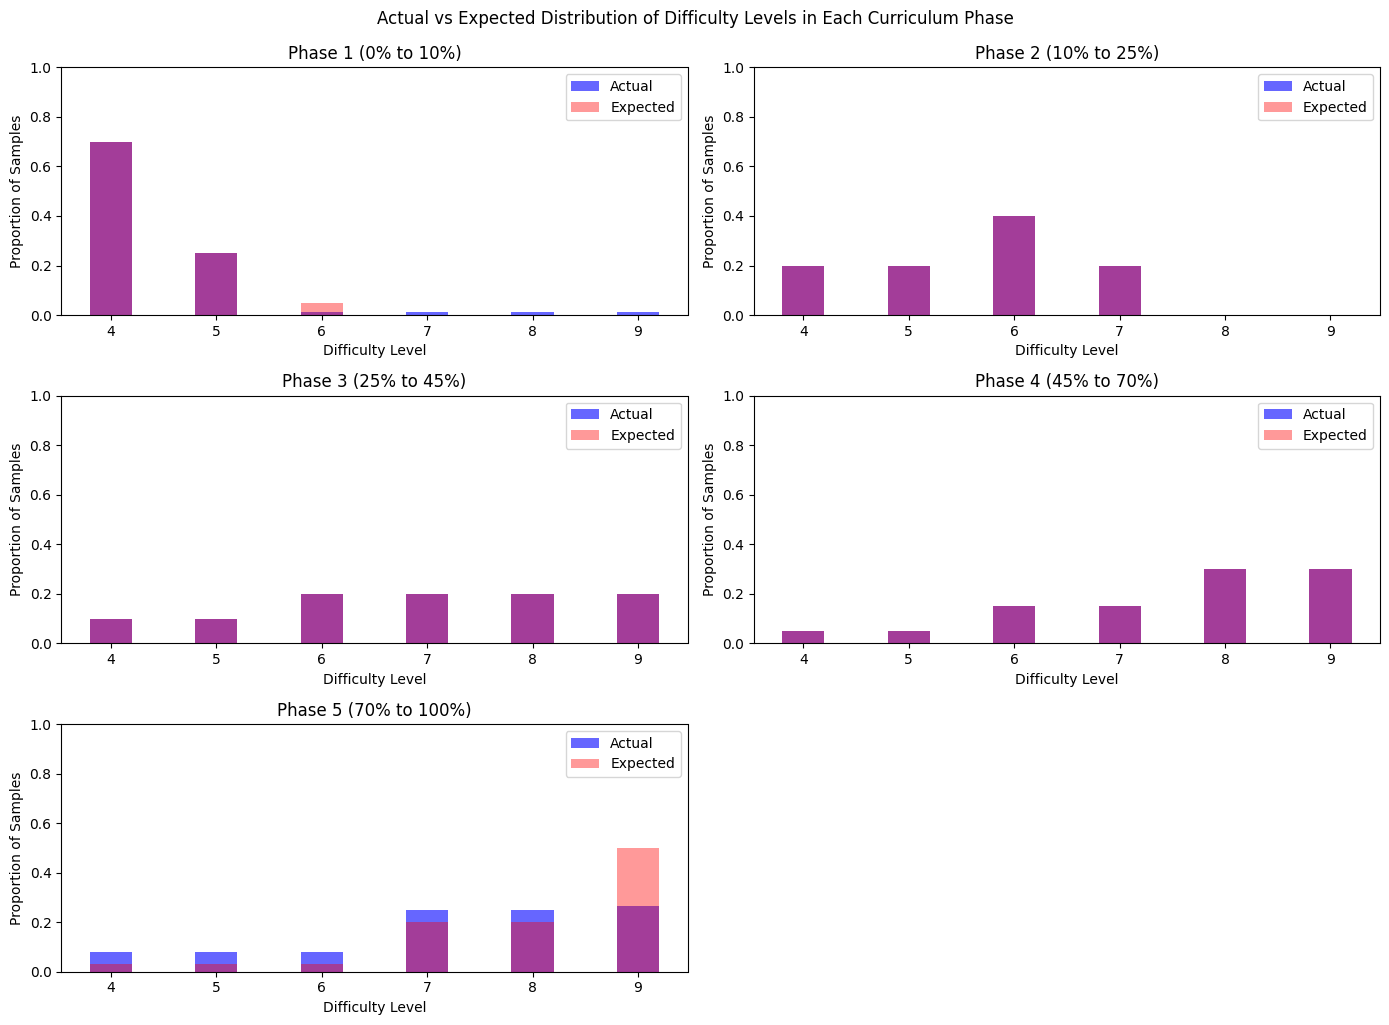

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
import os
import numpy as np

# Load the curriculum dataset
curriculum_dataset = pd.read_parquet(f"{os.environ['HF_HOME']}/data/countdown_4to9_phased_curriculum/train.parquet")

# Convert to list of dictionaries
curriculum_data_dicts = curriculum_dataset.to_dict(orient='records')

# Calculate levels for the curriculum dataset
curriculum_levels = calculate_level(curriculum_data_dicts)

# Define the phases and their expected level distributions
phases = [
    (0.00, 0.10, [4, 5, 6, 7, 8, 9]),  # Levels for phase 1
    (0.10, 0.25, [4, 5, 6, 7, 8, 9]),  # Levels for phase 2
    (0.25, 0.45, [4, 5, 6, 7, 8, 9]),  # Levels for phase 3
    (0.45, 0.70, [4, 5, 6, 7, 8, 9]),  # Levels for phase 4
    (0.70, 1.00, [4, 5, 6, 7, 8, 9])   # Levels for phase 5
]

# Expected level distributions based on the phased curriculum
expected_distributions = [
    {4: 0.70, 5: 0.25, 6: 0.05},  # Phase 1
    {4: 0.20, 5: 0.20, 6: 0.40, 7: 0.20},  # Phase 2
    {4: 0.10, 5: 0.10, 6: 0.20, 7: 0.20, 8: 0.20, 9: 0.20},  # Phase 3
    {4: 0.05, 5: 0.05, 6: 0.15, 7: 0.15, 8: 0.30, 9: 0.30},  # Phase 4
    {4: 0.033, 5: 0.033, 6: 0.033, 7: 0.20, 8: 0.20, 9: 0.50}  # Phase 5
]

# Calculate the distribution of difficulty levels in each phase
phase_distributions = []
total_samples = len(curriculum_levels)
for start, end, levels in phases:
    phase_start_idx = int(start * total_samples)
    phase_end_idx = int(end * total_samples)
    phase_levels = curriculum_levels[phase_start_idx:phase_end_idx]
    level_counts = {level: phase_levels.count(level) for level in levels}
    phase_distributions.append(level_counts)

# Plotting
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 10))
axes = axes.flatten()

for i, (start, end, levels) in enumerate(phases):
    phase_distribution = phase_distributions[i]
    expected_distribution = expected_distributions[i]
    total_phase_samples = sum(phase_distribution.values())
    
    # Plot actual vs expected distribution as a stacked bar chart
    actual_proportions = [phase_distribution.get(level, 0) / total_phase_samples for level in levels]
    expected_proportions = [expected_distribution.get(level, 0) for level in levels]
    axes[i].bar(levels, actual_proportions, width=0.4, label='Actual', color='b', alpha=0.6)
    axes[i].bar(levels, expected_proportions, width=0.4, label='Expected', color='r', alpha=0.4)
    
    axes[i].set_title(f'Phase {i+1} ({int(start*100)}% to {int(end*100)}%)')
    axes[i].set_xlabel('Difficulty Level')
    axes[i].set_ylabel('Proportion of Samples')
    axes[i].set_ylim(0, 1)
    axes[i].legend()

# Hide the last subplot if not used
if len(phases) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.suptitle('Actual vs Expected Distribution of Difficulty Levels in Each Curriculum Phase', y=1.02)
plt.show()
